# YAFS Simulation Trace Analysis

This notebook analyzes the `sim_trace.csv` file generated by the YAFS simulation. It focuses on:
- **Latency Analysis**: End-to-end delay of messages.
- **Service Time**: Processing time within modules.
- **Traffic Distribution**: Message counts per application and module.
- **Topology Flow**: Communication patterns between Fog and Cloud nodes.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load and Inspect Data
Load the CSV file and check the structure.

In [10]:
# Load the dataset
# Update to the specific results file generated by the tutorial
file_path = 'resultados/4-custom_proposed_by_felipe-sim_trace.csv'
df = pd.read_csv(file_path)

# Display first rows
display(df.head())

# Check info
print(df.info())

,id,type,app,module,message,DES.src,DES.dst,TOPO.src,TOPO.dst,TOPO.srcLabel,TOPO.dstLabel,module.src,service,time_in,time_out,time_emit,time_reception
0,34,COMP_M,Application-34,Application-34-Service,M_Req,181,179,92,2,Application-34-Sensor,Fog-1,Application-34-Sensor,0.022638,109.454986,109.477624,100.0,109.454986
1,23,COMP_M,Application-23,Application-23-Service,M_Req,148,146,70,2,Application-23-Sensor,Fog-1,Application-23-Sensor,0.018701,109.692204,109.710904,100.0,109.692204
2,41,COMP_M,Application-41,Application-41-Service,M_Req,202,200,106,3,Application-41-Sensor,Fog-2,Application-41-Sensor,0.021316,110.253638,110.274954,100.0,110.253638
3,16,COMP_M,Application-16,Application-16-Service,M_Req,127,125,56,4,Application-16-Sensor,Fog-3,Application-16-Sensor,0.019507,110.564421,110.583928,100.0,110.564421
4,71,COMP_M,Application-71,Application-71-Service,M_Req,292,290,166,1,Application-71-Sensor,Fog-0,Application-71-Sensor,0.023399,111.540209,111.563608,100.0,111.540209


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14136 entries, 0 to 14135
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              14136 non-null  int64  
 1   type            14136 non-null  object 
 2   app             14136 non-null  object 
 3   module          14136 non-null  object 
 4   message         14136 non-null  object 
 5   DES.src         14136 non-null  int64  
 6   DES.dst         14136 non-null  int64  
 7   TOPO.src        14136 non-null  int64  
 8   TOPO.dst        14136 non-null  int64  
 9   TOPO.srcLabel   14136 non-null  object 
 10  TOPO.dstLabel   14136 non-null  object 
 11  module.src      14136 non-null  object 
 12  service         14136 non-null  float64
 13  time_in         14136 non-null  float64
 14  time_out        14136 non-null  float64
 15  time_emit       14136 non-null  float64
 16  time_reception  14136 non-null  float64
dtypes: float64(5), int64(5), object

## 2. Data Preprocessing
Calculate key metrics:
- **Latency**: `time_reception - time_emit`
- **Service Time**: `time_out - time_in`
- **Network/Wait Time**: `Latency - Service Time`

In [11]:
# Calculate Latency
df['Latency'] = df['time_reception'] - df['time_emit']

# Calculate Service Time (Processing Duration)
df['Service_Time'] = df['time_out'] - df['time_in']

# Calculate Network + Wait Time
df['Network_Wait_Time'] = df['Latency'] - df['Service_Time']

# Create a combined label for Application and Node
df['App_Node'] = df['app'] + ' (' + df['TOPO.dstLabel'] + ')'

# Display summary stats for these new metrics
df[['Latency', 'Service_Time', 'Network_Wait_Time']].describe()

,Latency,Service_Time,Network_Wait_Time
count,14136.000000,14136.000000,14136.000000
mean,209.540849,0.262458,209.278390
std,702.182268,0.614222,701.856322
min,9.454502,0.013902,9.197076
25%,13.993796,0.019685,13.715292
50%,16.806764,0.222222,16.625724
75%,30.348204,0.301205,30.325566
max,7188.427049,4.800000,7188.142646


## 3. Descriptive Statistics
Analyze the frequency of applications, modules, and message types.

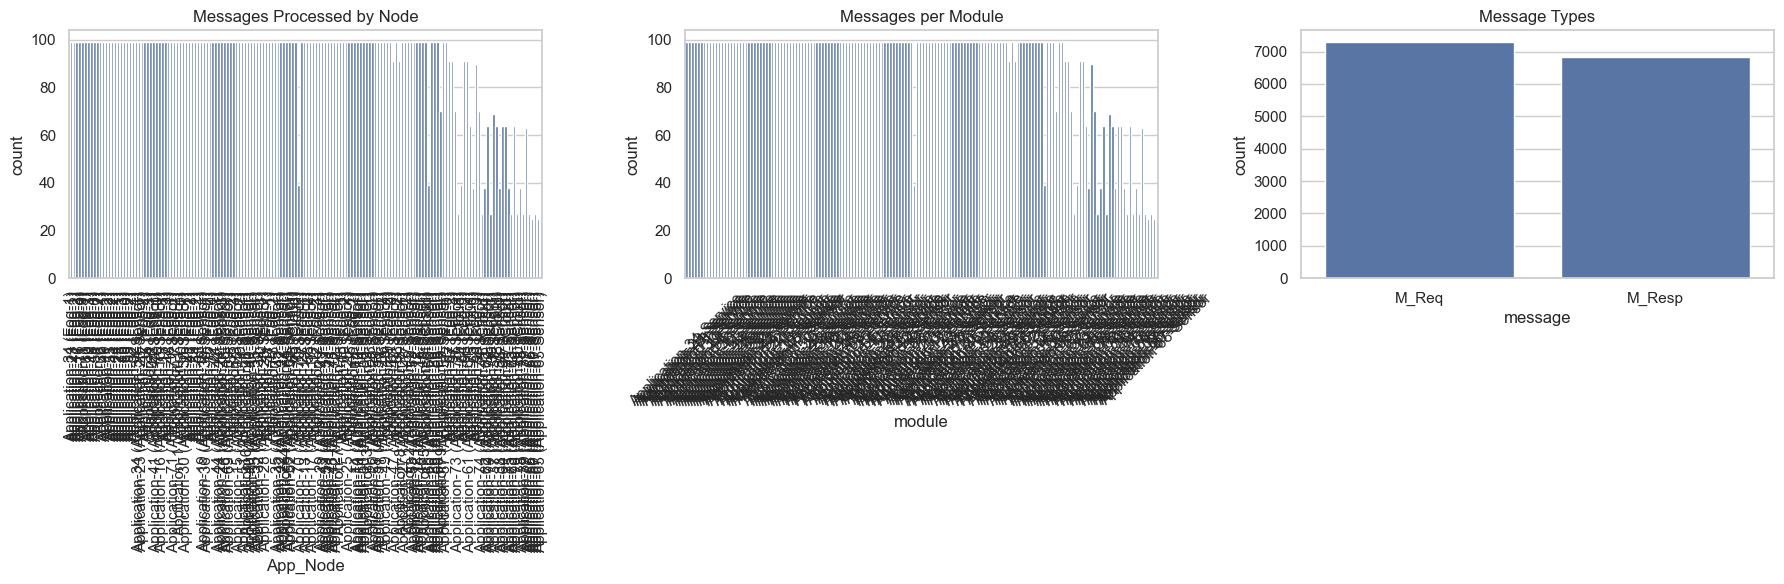

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Messages Processed by Node (Placement)
# We show all nodes now since Sensors and Actuators also process messages (M_Resp, M_Act)
sns.countplot(x='App_Node', data=df, ax=axes[0])
axes[0].set_title('Messages Processed by Node')
axes[0].tick_params(axis='x', rotation=90)

# 2. Messages per Module
sns.countplot(x='module', data=df, ax=axes[1])
axes[1].set_title('Messages per Module')
axes[1].tick_params(axis='x', rotation=45)

# 3. Message Types
# We use the 'message' column to distinguish M_Req, M_Resp, M_Act
sns.countplot(x='message', data=df, ax=axes[2])
axes[2].set_title('Message Types')

plt.tight_layout()
plt.show()

## 4. Latency Analysis
Visualize the distribution of latency and compare it across applications.

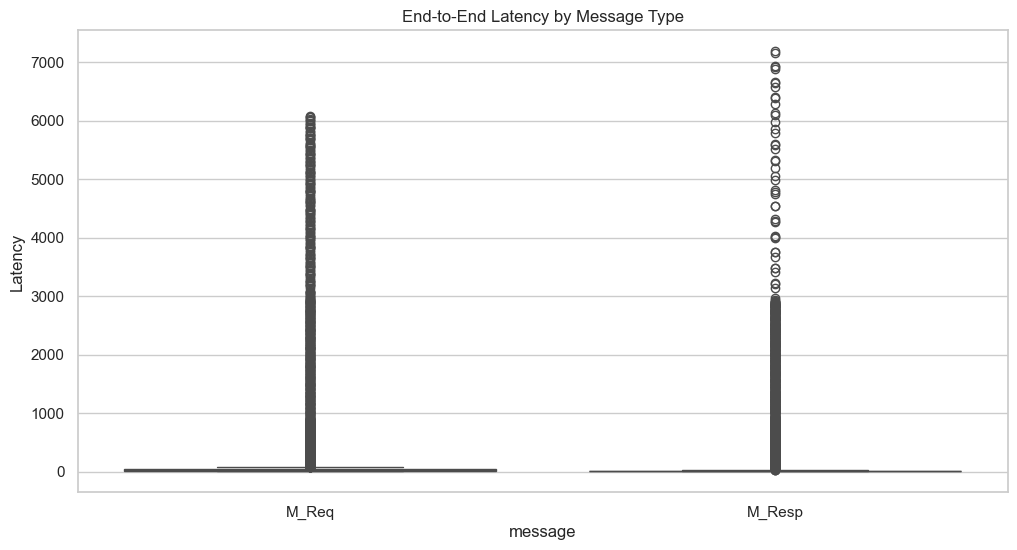

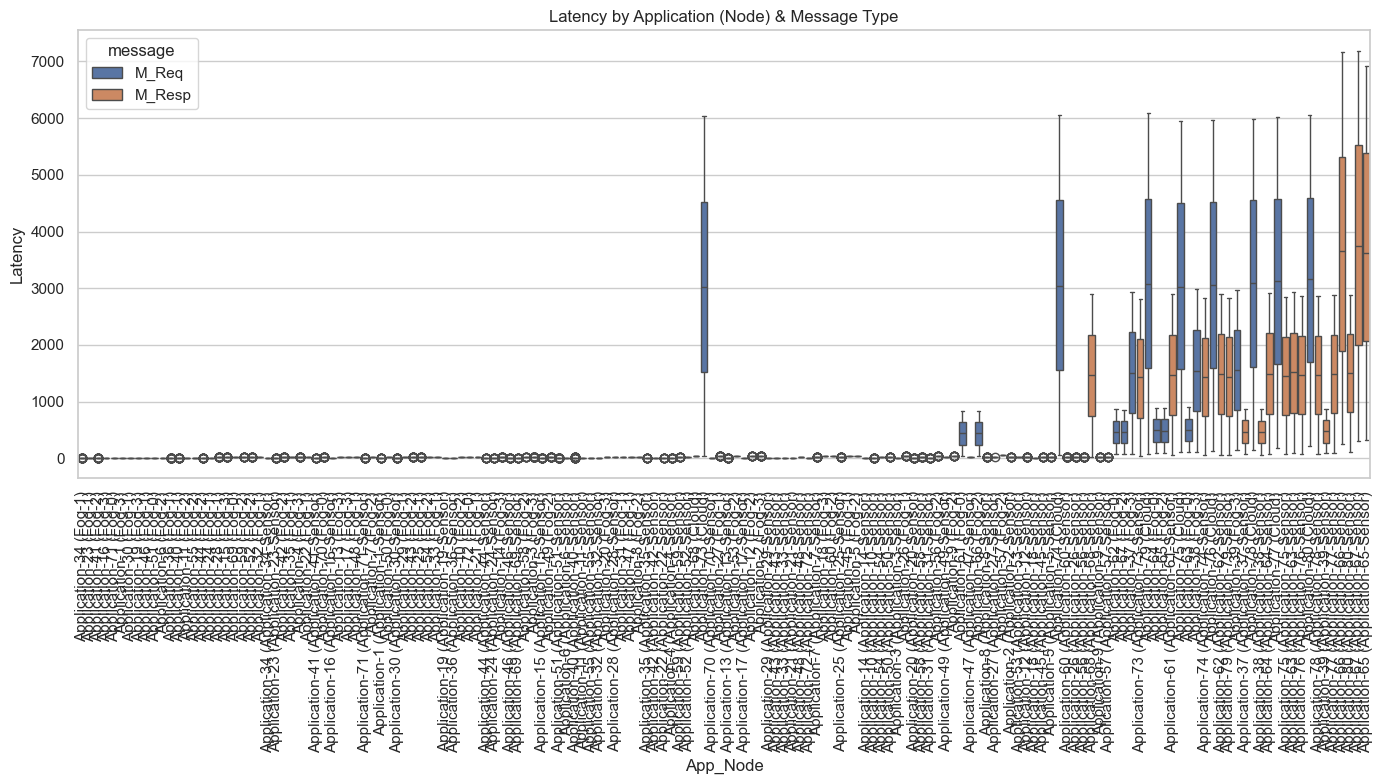

In [13]:
# Latency Distribution by Message Type
plt.figure(figsize=(12, 6))
sns.boxplot(x='message', y='Latency', data=df)
plt.title('End-to-End Latency by Message Type')
plt.show()

# Latency by Application and Node
plt.figure(figsize=(14, 8))
sns.boxplot(x='App_Node', y='Latency', hue='message', data=df)
plt.title('Latency by Application (Node) & Message Type')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 5. Service Time Analysis
Compare processing times across different nodes (Fog vs Cloud).

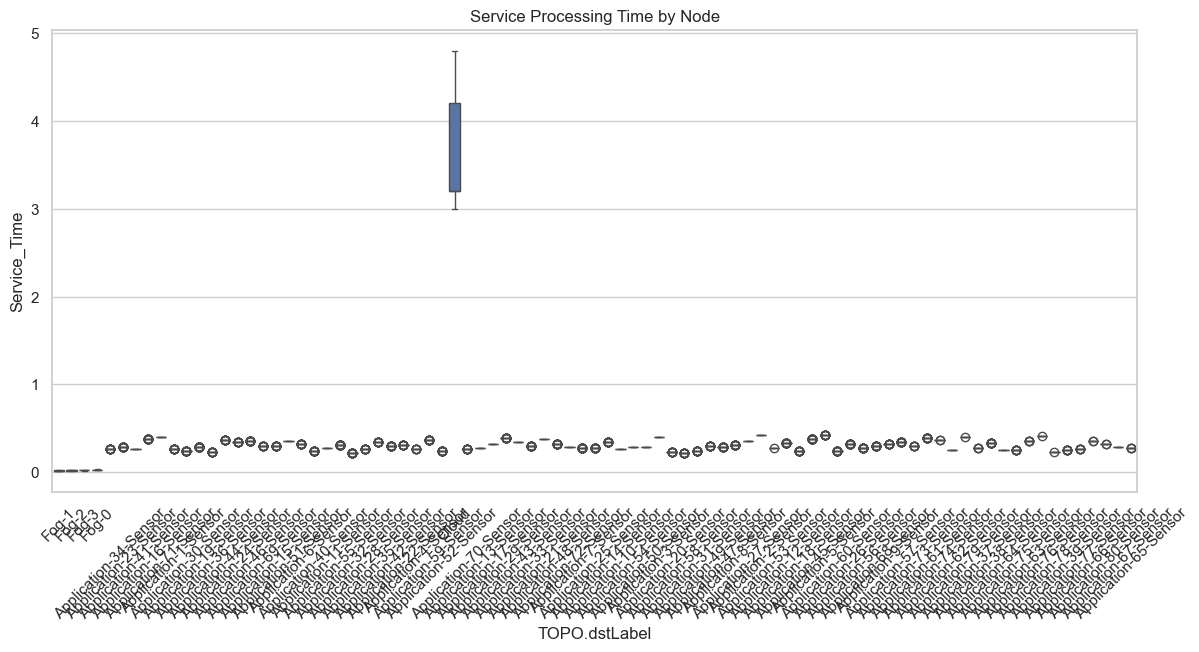

In [14]:
# Service Time by Node Label
plt.figure(figsize=(14, 6))
sns.boxplot(x='TOPO.dstLabel', y='Service_Time', data=df)
plt.title('Service Processing Time by Node')
plt.xticks(rotation=45)
plt.show()

## 6. Traffic Load Over Time
Check if the traffic is constant or bursty.

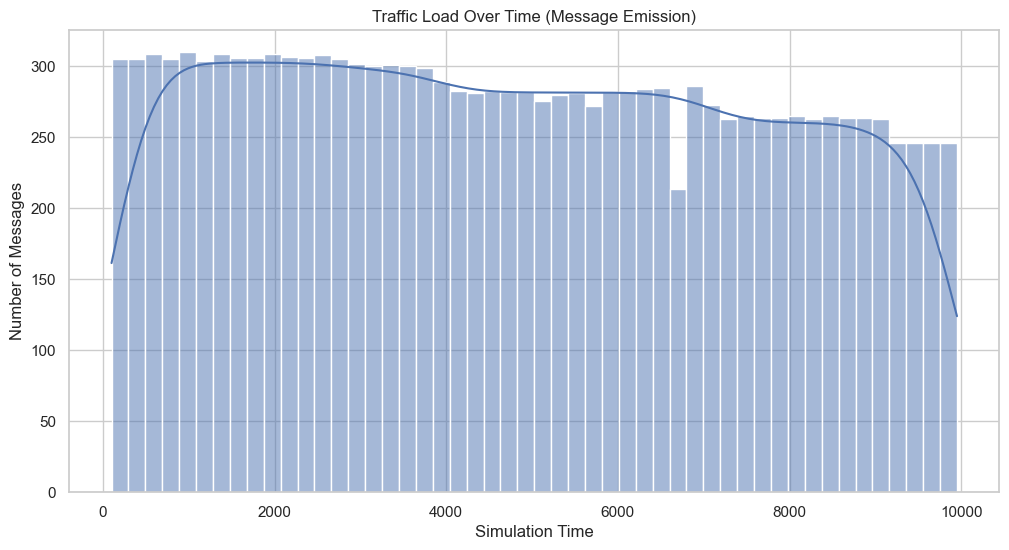

In [15]:
plt.figure(figsize=(12, 6))
sns.histplot(df['time_emit'], bins=50, kde=True)
plt.title('Traffic Load Over Time (Message Emission)')
plt.xlabel('Simulation Time')
plt.ylabel('Number of Messages')
plt.show()

## 7. Network Topology Flow
Visualize the communication frequency between different nodes.

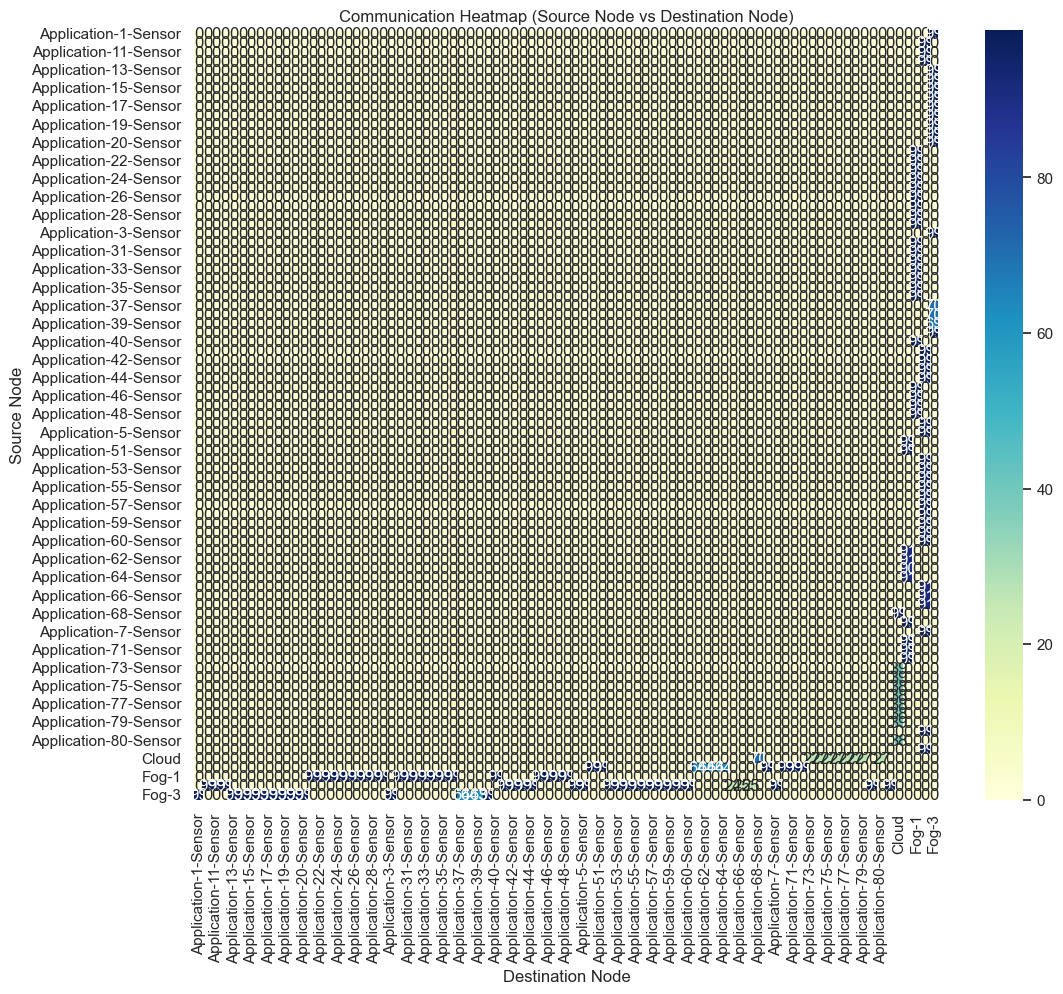

In [16]:
# Create a pivot table for the heatmap
heatmap_data = pd.crosstab(df['TOPO.srcLabel'], df['TOPO.dstLabel'])

plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Communication Heatmap (Source Node vs Destination Node)')
plt.xlabel('Destination Node')
plt.ylabel('Source Node')
plt.show()

## 8. Conclusion
This notebook provides a comprehensive overview of the simulation results.
- **Latency**: Check the boxplots to see if any application suffers from high latency.
- **Service Time**: Compare Fog vs Cloud nodes to see if Fog nodes are processing faster or if they are overloaded.
- **Traffic**: Ensure the load is distributed as expected and not saturating specific nodes (check the Heatmap).